✅ Dataset loaded!
   Shape       : (2484, 4)
   Columns     : ['ID', 'Resume_str', 'Resume_html', 'Category']
   Missing vals: 0

📊 Resume count per category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


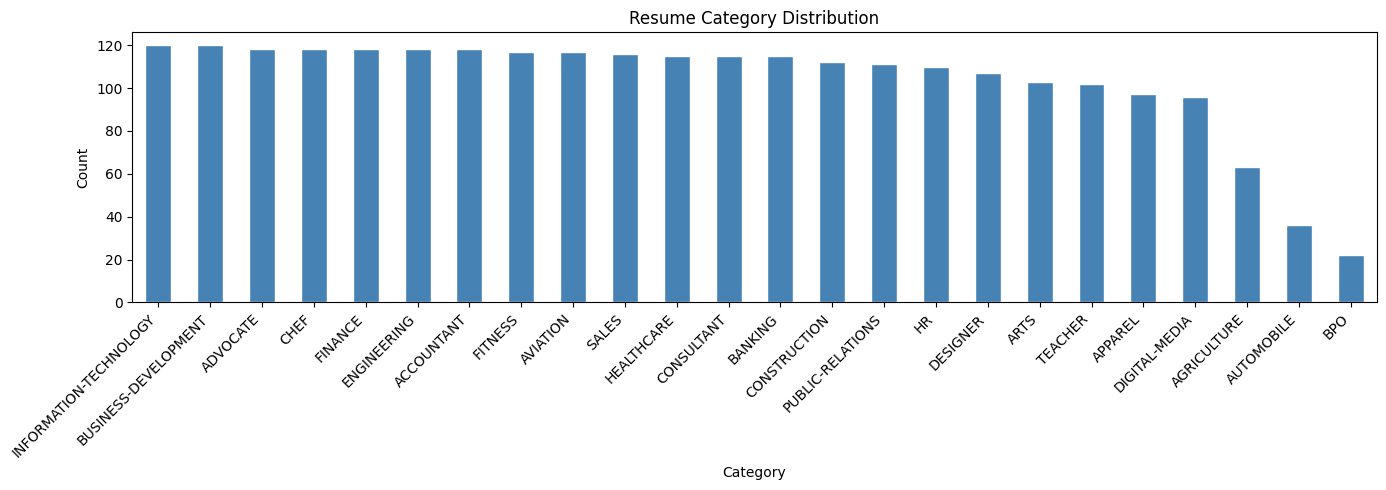

✅ Plot saved → results/plots/resume_category_distribution.png


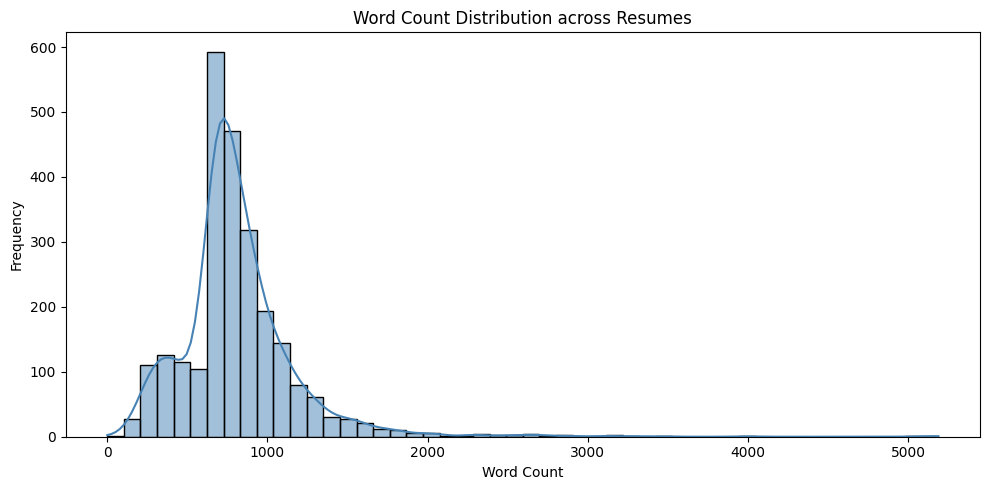

✅ Plot saved → results/plots/word_count_distributions.png


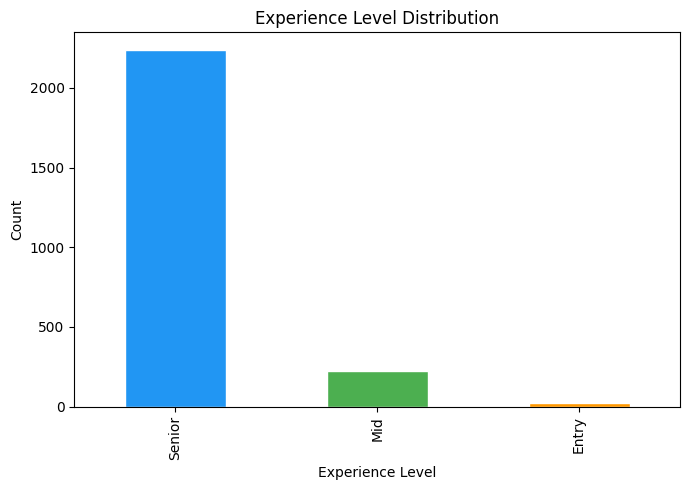

✅ Plot saved → results/plots/experience_level_distribution.png
✅ Dataset updated with word_count and experience_level columns


In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../results/plots", exist_ok=True)

# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
df = pd.read_csv("../data/resume.csv")

print("✅ Dataset loaded!")
print(f"   Shape       : {df.shape}")
print(f"   Columns     : {df.columns.tolist()}")
print(f"   Missing vals: {df.isnull().sum().sum()}")
df.head(3)

# ── Cell 3: Category Distribution ─────────────────────────────────────────────
print("\n📊 Resume count per category:")
print(df['Category'].value_counts())

plt.figure(figsize=(14, 5))
df['Category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Resume Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../results/plots/resume_category_distribution.png", dpi=150)
plt.show()
print("✅ Plot saved → results/plots/resume_category_distribution.png")

# ── Cell 4: Word Count Distribution ───────────────────────────────────────────
df['word_count'] = df['Resume_str'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, color='steelblue', kde=True)
plt.title('Word Count Distribution across Resumes')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("../results/plots/word_count_distributions.png", dpi=150)
plt.show()
print("✅ Plot saved → results/plots/word_count_distributions.png")

# ── Cell 5: Experience Level Distribution ─────────────────────────────────────
# Assign experience level based on word count
def get_experience_level(text):
    words = len(str(text).split())
    if words < 200:
        return 'Entry'
    elif words < 400:
        return 'Mid'
    else:
        return 'Senior'

df['experience_level'] = df['Resume_str'].apply(get_experience_level)

plt.figure(figsize=(7, 5))
df['experience_level'].value_counts().plot(kind='bar', color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
plt.title('Experience Level Distribution')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("../results/plots/experience_level_distribution.png", dpi=150)
plt.show()
print("✅ Plot saved → results/plots/experience_level_distribution.png")

# ── Cell 6: Save enriched dataframe ───────────────────────────────────────────
df.to_csv("../data/resume_dataset.csv", index=False)
print("✅ Dataset updated with word_count and experience_level columns")